In [12]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from tools import *
from fit_funcs import *
from entropy import *
import costfun.costfun as cost
import utils.figures as fig_help
from RandomMatrixTheory import goe
import utils.tools as tools

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# plt.rcParams["mathtext.fontset"] = "cm"
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

linestyle_ls = ['-','--',':', '-.']
linestyle = itertools.cycle(linestyle_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   
from scipy import stats

# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import lambertw
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import splrep, splev
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import interp1d
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import fsolve

from mpl_toolkits.axes_grid1 import make_axes_locatable

# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists


config_disorder = 0
scaled_disorder = 0

if config_disorder:
    base_dir = "../results_conf_dis/"
else:
    base_dir = "../results/"

print(base_dir[2:])
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}


/Users/rafal.swietek/Projects/CODES/QHamSolver/QuantumSun/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
/results/


### SAVER & DATA COLLECTOR

In [15]:
L=8
J=1.0
alfa=1.0
h=1.0
w=0.5
zeta=0.2
gamma=1.0

conf_disorder = False

N=3
J=1
scaled_dis = 0

ini_ave=1
num_realis = 20

def loop_body(L, alfa):
    L_total = L+N
    dim = 2**L_total

    S_GS = np.zeros((L_total + 1))
    S_EX = np.zeros((L_total + 1))
    S_site_GS = np.zeros((L_total + 1))
    S_site_EX = np.zeros((L_total + 1))
    
    Sx_GS = np.zeros((L_total))
    Sy_GS = np.zeros((L_total), dtype=complex)
    Sz_GS = np.zeros((L_total))
    Sx_EX = np.zeros((L_total))
    Sy_EX = np.zeros((L_total), dtype=complex)
    Sz_EX = np.zeros((L_total))
    
    SxSx_GS = np.zeros((L_total, L_total))
    SySy_GS = np.zeros((L_total, L_total))
    SzSz_GS = np.zeros((L_total, L_total))
    SxSx_EX = np.zeros((L_total, L_total))
    SySy_EX = np.zeros((L_total, L_total))
    SzSz_EX = np.zeros((L_total, L_total))
    counter = 0

    # w = np.round(w, 6)
    alfa = np.round(alfa, 6)

    print(info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', scaled_disorder=scaled_dis, ini_ave = ini_ave), flush=True)

    energy_gap = 0
    for real in range(num_realis):
        name = base_dir + 'GroundState/TESTS/realisation=%d/'%real + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ini_ave = ini_ave, ext='.hdf5', scaled_disorder=scaled_dis)
        if exists(name):
            with h5py.File(name, "r") as file:
                try:
                    _var_names1 = ['energies', 'entropy GS', 'single_site_entropy GS', 'entropy excited', 'single_site_entropy excited', 'subsystem sizes']
                    _var_names2 = ['Sx GS', 'Sy GS', 'Sz GS', 'Sx excited', 'Sy excited', 'Sz excited', 'SxSx GS', 'SySy GS', 'SzSz GS', 'SxSx excited', 'SySy excited', 'SzSz excited']
                    for _name_var in [*_var_names1, *_var_names2]:
                        _name_var_funt = _name_var;
                        xx = np.array(file.get(_name_var)[0])
                    
                except (IndexError, OSError, TypeError) as e:
                    print("FAILED AT: ", _name_var_funt, "\tCorrupted file!", name, flush=True)
                    print("\t\tERROR", e, flush=True)
                
                E = np.array(file.get('energies')[0])
                energy_gap += E[1] - E[0]
                
                # ENTANGLEMENT ENTROPIES
                S_GS += np.array(file.get('entropy GS')[0])
                S_EX += np.array(file.get('entropy excited')[0])
                S_site_GS += np.array(file.get('single_site_entropy GS')[0])
                S_site_EX += np.array(file.get('single_site_entropy excited')[0])
                
                # EXPECTATION VALUES
                Sx_GS += np.array(file.get('Sx GS')[0])
                Sy_GS += np.array(file.get('Sy GS')[0]).view(complex)
                Sz_GS += np.array(file.get('Sz GS')[0])
                Sx_EX += np.array(file.get('Sx excited')[0])
                Sy_EX += np.array(file.get('Sy excited')[0]).view(complex)
                Sz_EX += np.array(file.get('Sz excited')[0])
                
                # CORRELATION MATRICES
                SxSx_GS += np.array(file.get('SxSx GS'))
                SySy_GS += np.array(file.get('SySy GS'))
                SzSz_GS += np.array(file.get('SzSz GS'))
                SxSx_EX += np.array(file.get('SxSx excited'))
                SySy_EX += np.array(file.get('SySy excited'))
                SzSz_EX += np.array(file.get('SzSz excited'))
                
                counter += 1
        else:
            asdbcinoas=1
#                print(real)
    print(L, gamma, alfa, counter, flush=True)
    if counter > 0:
        name = base_dir + 'GroundState/TESTS/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ext='.hdf5', scaled_disorder=scaled_dis)

        hf = h5py.File(name, 'w')
        hf['energy gap'] = energy_gap / counter
        hf['realisations'] = counter
        
        hf.create_dataset('entropies GS', S_GS.shape, data = S_GS / counter)
        hf.create_dataset('single_site_entropy GS', S_site_GS.shape, data = S_site_GS / counter)
        hf.create_dataset('entropies excited', S_EX.shape, data = S_EX / counter)
        hf.create_dataset('single_site_entropy excited', S_site_EX.shape, data = S_site_EX / counter)
        
        hf.create_dataset('Sx GS', Sx_GS.shape, data = Sx_GS / counter)
        hf.create_dataset('Sy GS', Sy_GS.shape, data = Sy_GS / counter)
        hf.create_dataset('Sz GS', Sz_GS.shape, data = Sz_GS / counter)
        
        hf.create_dataset('Sx excited', Sx_EX.shape, data = Sx_EX / counter)
        hf.create_dataset('Sy excited', Sy_EX.shape, data = Sy_EX / counter)
        hf.create_dataset('Sz excited', Sz_EX.shape, data = Sz_EX / counter)
        
        hf.create_dataset('SxSx GS', SxSx_GS.shape, data = SxSx_GS / counter)
        hf.create_dataset('SySy GS', SySy_GS.shape, data = SySy_GS / counter)
        hf.create_dataset('SzSz GS', SzSz_GS.shape, data = SzSz_GS / counter)
        
        hf.create_dataset('SxSx excited', SxSx_EX.shape, data = SxSx_EX / counter)
        hf.create_dataset('SySy excited', SySy_EX.shape, data = SySy_EX / counter)
        hf.create_dataset('SzSz excited', SzSz_EX.shape, data = SzSz_EX / counter)
        
        


        hf.close()


L = 13
alfa = 0.8
for L in np.arange(9, 15, 1):
    for alfa in np.arange(0.8, 1.2, 0.04):
        loop_body(L, alfa)

_L=9,N=3,J=1,g=1,zeta=0.2,alfa=0.8,h=1,w=0.5,ini_ave.hdf5
9 1.0 0.8 20
_L=9,N=3,J=1,g=1,zeta=0.2,alfa=0.84,h=1,w=0.5,ini_ave.hdf5
9 1.0 0.84 20
_L=9,N=3,J=1,g=1,zeta=0.2,alfa=0.88,h=1,w=0.5,ini_ave.hdf5
9 1.0 0.88 20
_L=9,N=3,J=1,g=1,zeta=0.2,alfa=0.92,h=1,w=0.5,ini_ave.hdf5
9 1.0 0.92 20
_L=9,N=3,J=1,g=1,zeta=0.2,alfa=0.96,h=1,w=0.5,ini_ave.hdf5
9 1.0 0.96 20
_L=9,N=3,J=1,g=1,alfa=1,h=1,w=0.5,ini_ave.hdf5
9 1.0 1.0 20
_L=9,N=3,J=1,g=1,zeta=0.2,alfa=1.04,h=1,w=0.5,ini_ave.hdf5
9 1.0 1.04 20
_L=9,N=3,J=1,g=1,zeta=0.2,alfa=1.08,h=1,w=0.5,ini_ave.hdf5
9 1.0 1.08 20
_L=9,N=3,J=1,g=1,zeta=0.2,alfa=1.12,h=1,w=0.5,ini_ave.hdf5
9 1.0 1.12 20
_L=9,N=3,J=1,g=1,zeta=0.2,alfa=1.16,h=1,w=0.5,ini_ave.hdf5
9 1.0 1.16 20
_L=10,N=3,J=1,g=1,zeta=0.2,alfa=0.8,h=1,w=0.5,ini_ave.hdf5
10 1.0 0.8 20
_L=10,N=3,J=1,g=1,zeta=0.2,alfa=0.84,h=1,w=0.5,ini_ave.hdf5
10 1.0 0.84 20
_L=10,N=3,J=1,g=1,zeta=0.2,alfa=0.88,h=1,w=0.5,ini_ave.hdf5
10 1.0 0.88 20
_L=10,N=3,J=1,g=1,zeta=0.2,alfa=0.92,h=1,w=0.5,ini_ave.hdf5
10

## PLOTTERS

In [ ]:
E = np.array(file.get('energies')[0])
            energy_gap = E[1] - E[0]
            
            # ENTANGLEMENT ENTROPIES
            S_GS = np.array(file.get('entropy GS')[0])
            S_EX = np.array(file.get('entropy excited')[0])
            S_site_GS = np.array(file.get('single_site_entropy GS')[0])
            S_site_EX = np.array(file.get('single_site_entropy excited')[0])
            
            # EXPECTATION VALUES
            Sx_GS = np.array(file.get('Sx GS')[0])
            Sy_GS = np.array(file.get('Sy GS')[0]).view(complex)
            Sz_GS = np.array(file.get('Sz GS')[0])
            Sx_EX = np.array(file.get('Sx excited')[0])
            Sy_EX = np.array(file.get('Sy excited')[0]).view(complex)
            Sz_EX = np.array(file.get('Sz excited')[0])
            
            # CORRELATION MATRICES
            SxSx_GS = np.array(file.get('SxSx GS'))
            SySy_GS = np.array(file.get('SySy GS'))
            SzSz_GS = np.array(file.get('SzSz GS'))
            SxSx_EX = np.array(file.get('SxSx excited'))
            SySy_EX = np.array(file.get('SySy excited'))
            SzSz_EX = np.array(file.get('SzSz excited'))

In [ ]:
def _calc_Sq(q, SxSx, SySy, SzSz):
    assert SxSx.shape != SySy.shape or SxSx.shape != SzSz.shape or SySy.shape != SzSz.shape
    _L, _ = SxSx.shape
    print(_L)

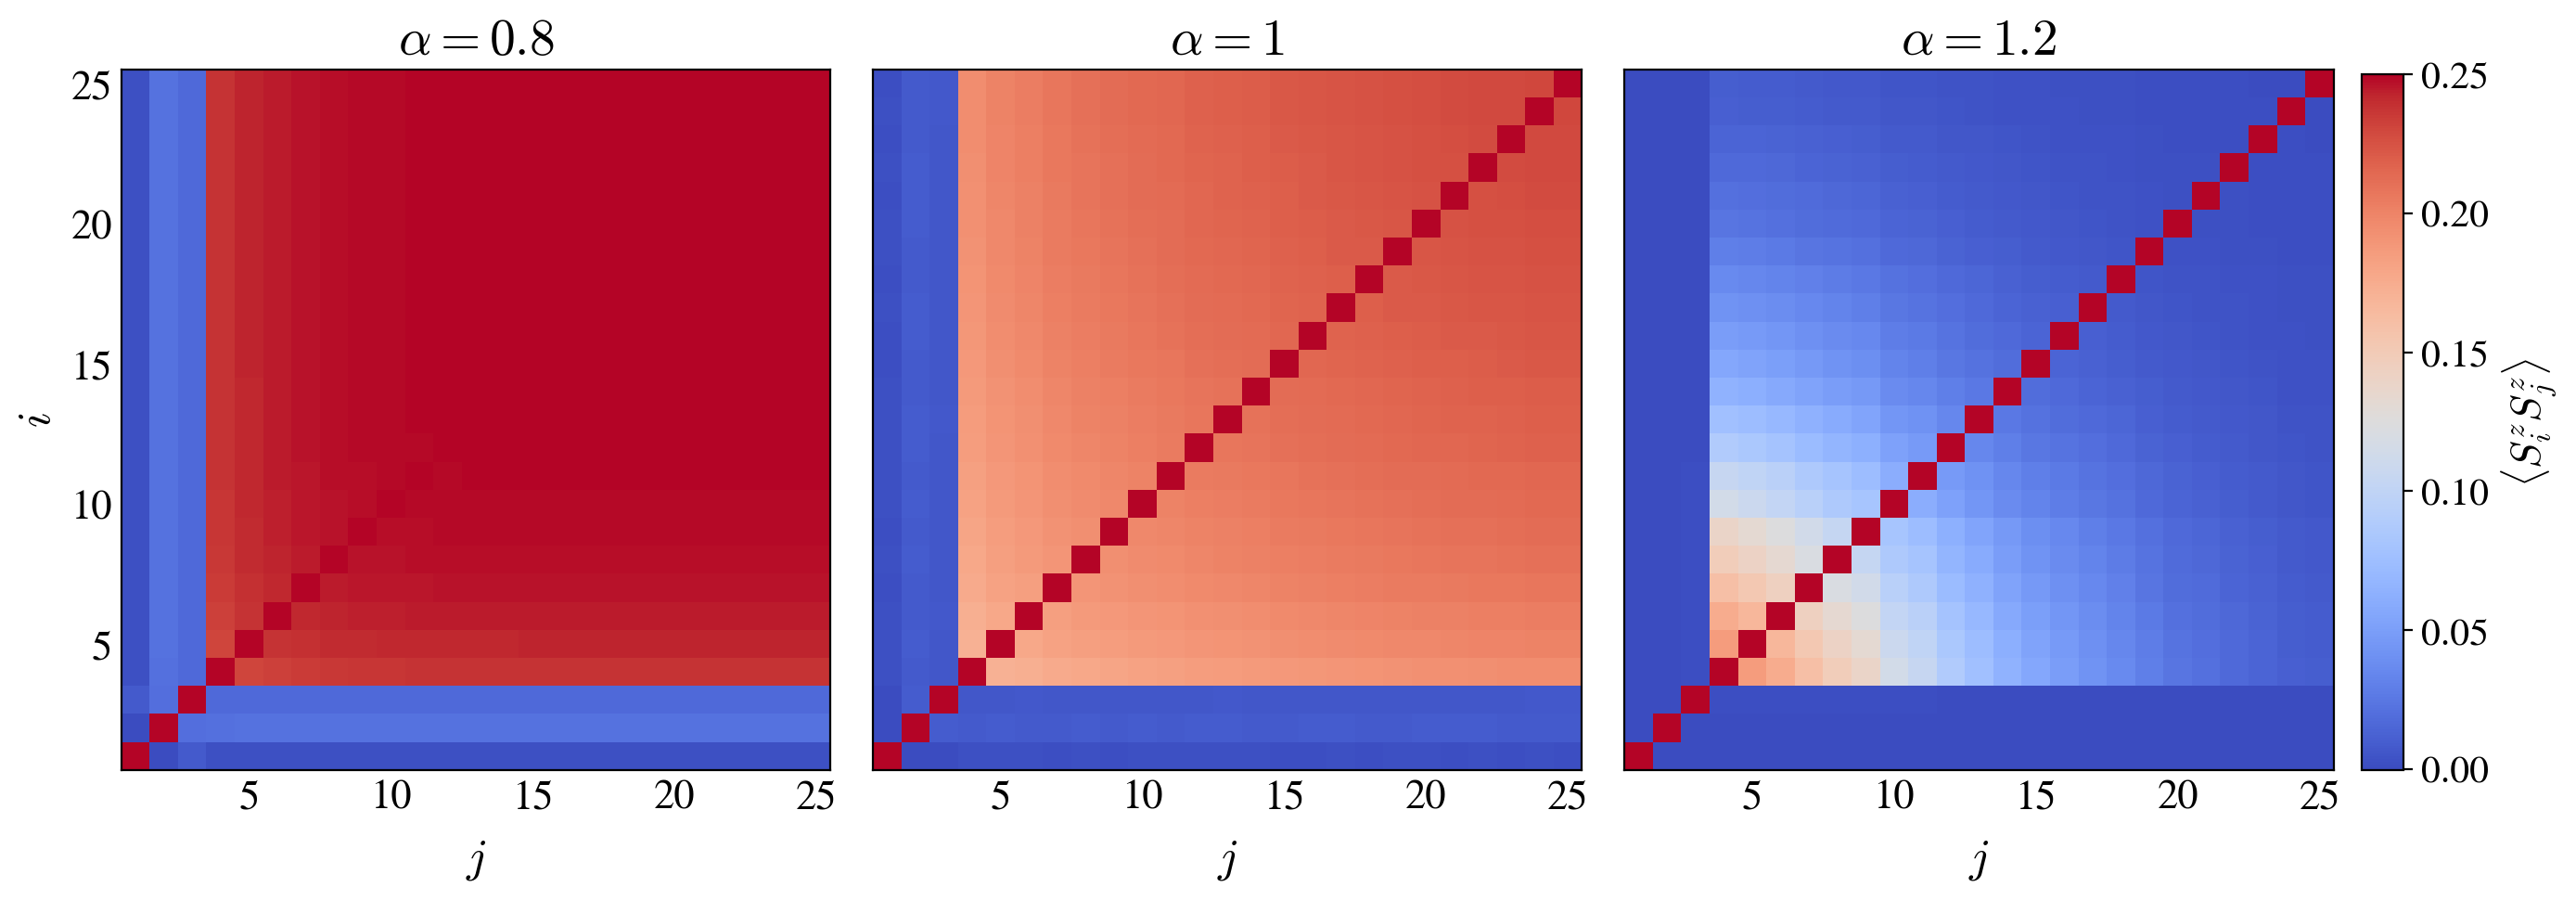

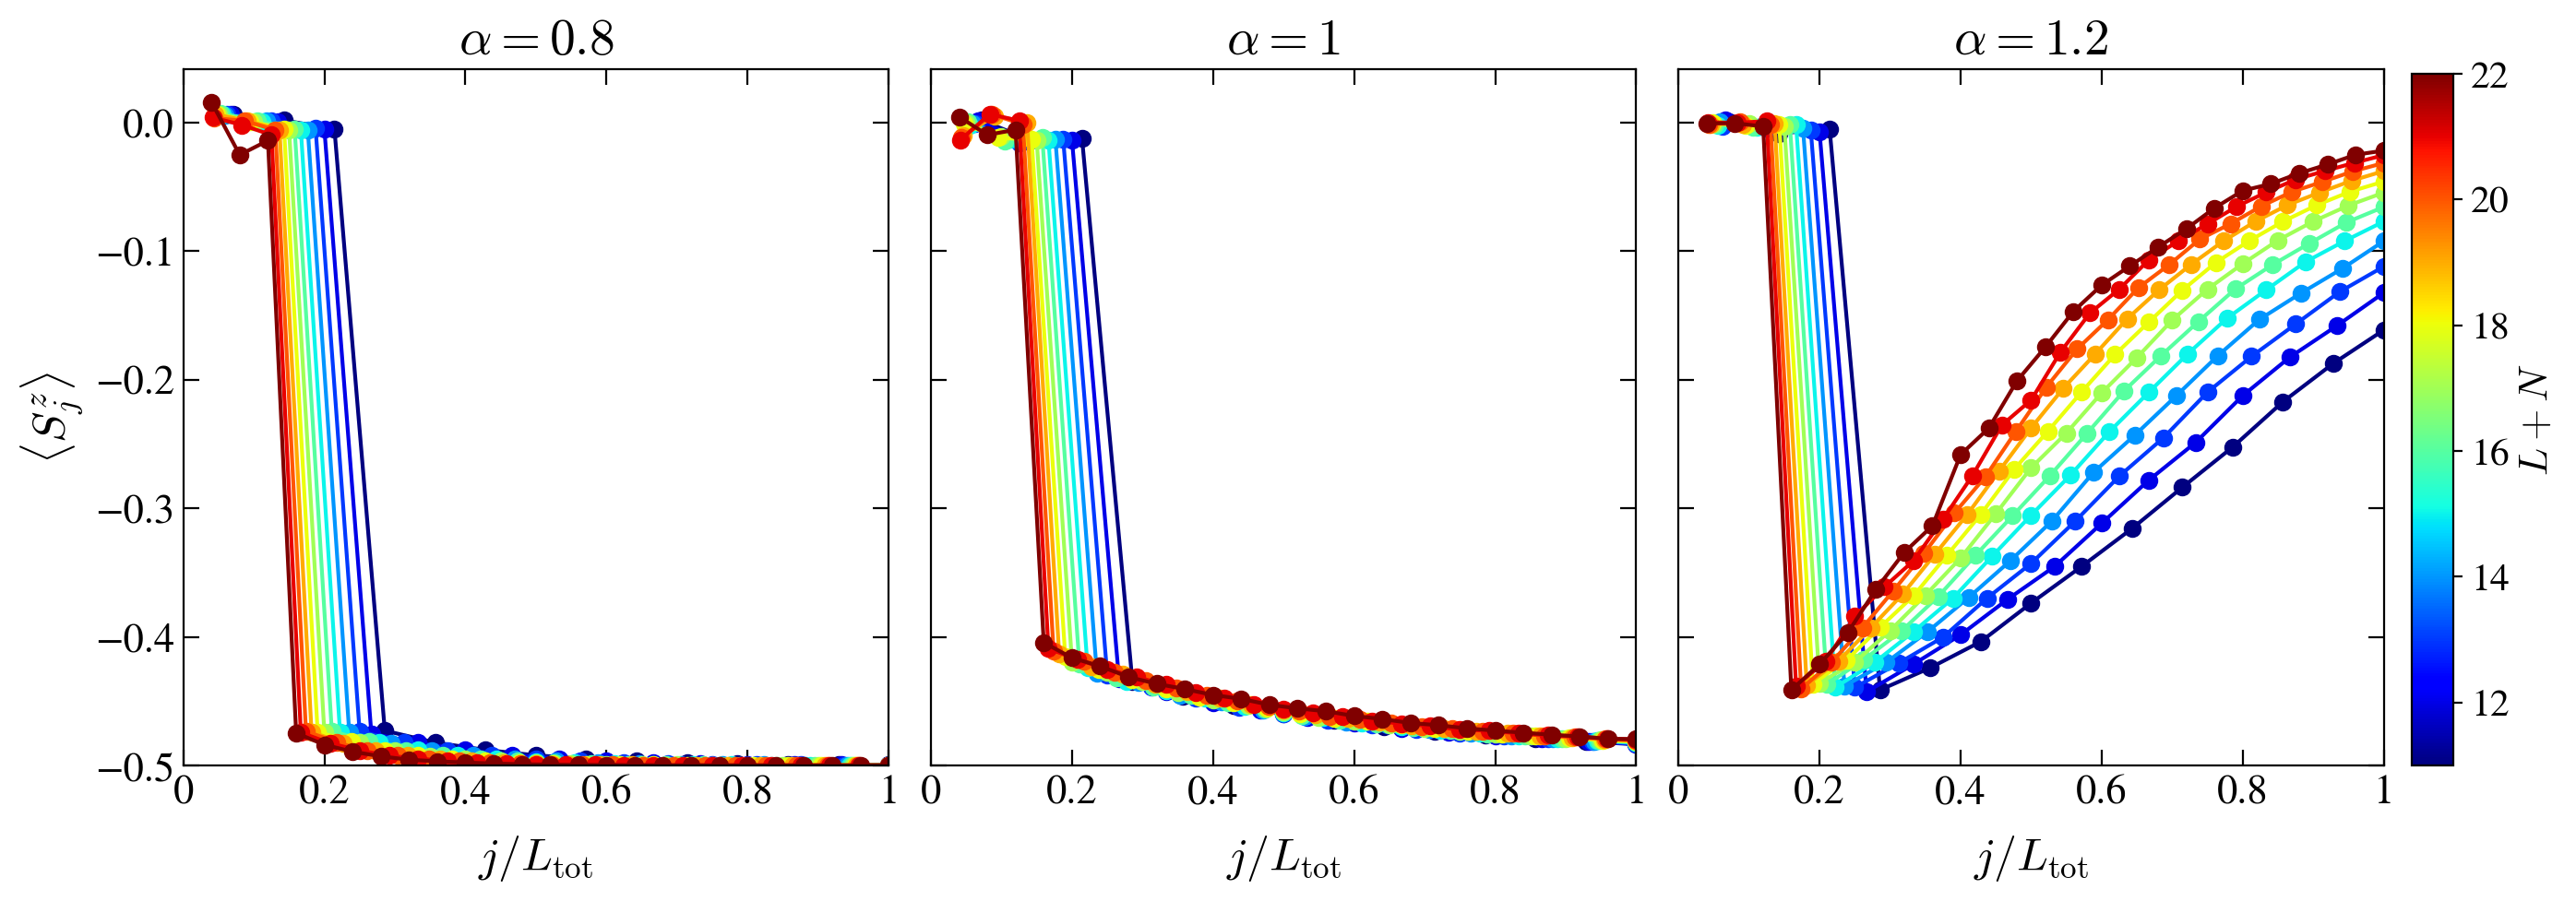

In [453]:
L=20
J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
gamma=1.0
conf_disorder = False

N=3
scaled_dis = 0

ini_ave = 0

Ltot = L + N
sizes = np.arange(11, 23, 1) if J == 1 else np.arange(11, 19, 1)
norm = matplotlib.colors.Normalize(
    vmin=np.min(sizes),
    vmax=np.max(sizes))


# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=3, figsize=(15, 5), dpi = 200, sharey = True)

fig2, axis2 = plt.subplots( nrows=1, ncols=3, figsize=(15, 5), dpi = 200, sharey = True)

upper = plt.get_cmap('coolwarm', 100)(np.linspace(0.0, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)


state = 'GS'
# state = 'excited'


for iia, alfa in enumerate([0.8, 1, 1.2]):
    for L in sizes:
        Ltot = L+N
        sites = np.arange(0, Ltot)+1
        # sites2 = np.arange(0, Ltot)
        X, Y = np.meshgrid(sites, sites)
        name = base_dir + 'GroundState/TESTS/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ini_ave = ini_ave, ext='.hdf5', scaled_disorder=scaled_dis)
        if exists(name):
            with h5py.File(name, "r") as file:
                SxSx_GS = np.array(file.get('SxSx ' + state)) #[N:, N:]
                SySy_GS = np.array(file.get('SySy ' + state)) #[N:, N:]
                SzSz_GS = np.array(file.get('SzSz ' + state)) #[N:, N:]
                corr = SxSx_GS + SySy_GS + SzSz_GS
                corr = SzSz_GS
                # for ii in range(corr.shape[0]): corr[ii, ii] = np.nan
                zz = corr[~np.isnan(corr)].flatten()
                # axis[iia].plot(np.arange(0, Ltot), corr_fun, marker='o')
                if (L == 22 and J == 1) or L==18:
                    p = axis[iia].pcolormesh(X, Y, corr, shading='nearest', cmap=mymap, vmin=min(zz), vmax=max(zz))
                
                Sz_GS = np.array(file.get('Sz ' + state)) #[N:]
                axis2[iia].plot( (sites) / Ltot, Sz_GS, marker='o', color=s_m.to_rgba(L))
        else:
            print(name)
        
    fig_help.set_plot_elements(axis[iia], ylabel="$i$" if iia == 0 else "", xlabel="$j$", font_size=16, set_legend=False, xscale='linear')
    axis[iia].set_title(r"$\alpha=%g$"%alfa, fontsize=20)
    
    fig_help.set_plot_elements(axis2[iia], ylabel=r"$\langle S^z_j\rangle$" if iia == 0 else "", xlabel=r"$j/L_{\rm tot}$", font_size=16, set_legend=False, xscale='linear')
    axis2[iia].set_title(r"$\alpha=%g$"%alfa, fontsize=20)
    axis2[iia].xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
    axis2[iia].xaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
    axis2[iia].set_xlim(0, 1)
    axis2[iia].set_ylim(-0.5, None)
    
    # cbar = None
    # divider = make_axes_locatable(axis[iia])
    # cax = divider.new_vertical(size = '4%', pad = 0.05)
    # fig.add_axes(cax)
    # cbar = fig.colorbar(p, cax = cax, orientation = 'horizontal')
    # cax.xaxis.set_ticks_position('top')
    # # cax.xaxis.set_label_position('top')
    # cax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
    # cax.xaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
    # axis[iia].annotate(r"$\alpha=%g$"%alfa, fontsize=18, xy=(0.02, -0.15), xycoords='axes fraction', bbox=dict(facecolor='none', edgecolor='black', boxstyle='round,pad=0.1'))

fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.93, 0.125, 0.015, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(p, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\langle S^z_iS^z_j\rangle$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig2.subplots_adjust(right=0.92)
cbar_ax = fig2.add_axes([0.93, 0.125, 0.015, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig2.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$L+N$", fontsize=16)
cbar.ax.tick_params(labelsize=15)


fig.subplots_adjust(wspace = 0.06, hspace=0.06)
fig2.subplots_adjust(wspace = 0.06, hspace=0.06)

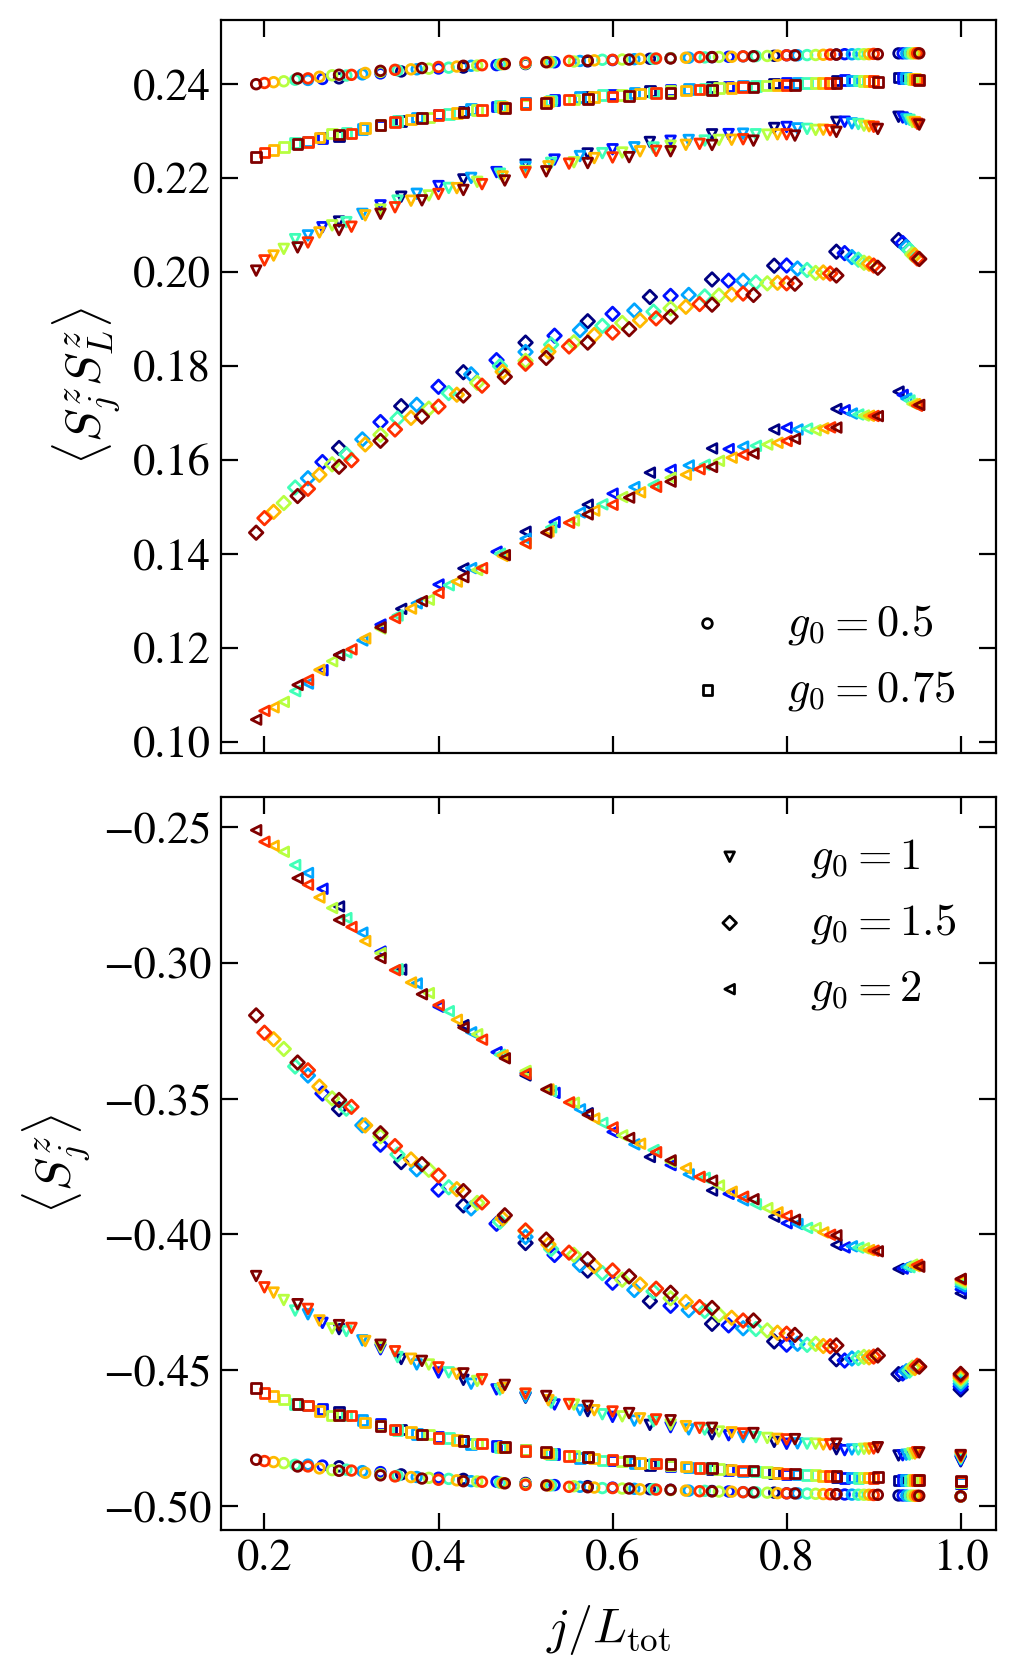

In [399]:
markers = itertools.cycle(markers_ls)

L=20
J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
gamma=1.0
conf_disorder = False

N=3
scaled_dis = 0

ini_ave = 0

Ltot = L + N
sizes = np.arange(11, 19, 1)
norm = matplotlib.colors.Normalize(
    vmin=np.min(sizes),
    vmax=np.max(sizes))


# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(5, 10), dpi = 200, sharex = True)


state = 'GS'
# state = 'excited'

alfa = 1
for iia, J in enumerate([0.5, 0.75, 1, 1.5, 2]):
    mar = next(markers)
    for L in sizes:
        Ltot = L+N
        sites = np.arange(N, Ltot)+1
        # sites2 = np.arange(0, Ltot)
        X, Y = np.meshgrid(sites, sites)
        name = base_dir + 'GroundState/TESTS/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ini_ave = ini_ave, ext='.hdf5', scaled_disorder=scaled_dis)
        if exists(name):
            with h5py.File(name, "r") as file:
                
                Sx_GS = np.array(file.get('SzSz ' + state))[-1][N:-1]# + np.array(file.get('SySy ' + state))[-1][N:-1] + np.array(file.get('SxSx ' + state))[-1][N:-1]
                axis[0].scatter( (sites[:-1]) / Ltot, Sx_GS, marker=mar, color=s_m.to_rgba(L), facecolor='None', s=12)
                
                Sz_GS = np.array(file.get('Sz ' + state))[N:]
                axis[1].scatter( (sites) / Ltot, (Sz_GS), marker=mar, color=s_m.to_rgba(L), facecolor='None', s=12)
        else:
            print(name)
    axis[0].scatter( np.nan, np.nan, marker=mar, color='k', facecolor='None', s=12, label = r"$g_0=%g$"%J if iia < 2 else "")
    axis[1].scatter( np.nan, np.nan, marker=mar, color='k', facecolor='None', s=12, label = r"$g_0=%g$"%J if iia >= 2 else "")
fig_help.set_plot_elements(axis[0], ylabel=r"$\langle S^z_jS^z_L\rangle$", xlabel=r"", font_size=16, set_legend=True)
fig_help.set_plot_elements(axis[1], ylabel=r"$\langle S^z_j\rangle$", xlabel=r"$j/L_{\rm tot}$", font_size=16, set_legend=True)

# axis[iia].xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
# axis[iia].xaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
# axis[iia].set_xlim(0, 1)
# axis[0].set_ylim(0, 0.25)
# axis[1].set_ylim(0.5, 0)


fig2.subplots_adjust(right=0.92)
cbar_ax = fig2.add_axes([0.93, 0.125, 0.015, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig2.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$L+N$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig.subplots_adjust(wspace = 0.06, hspace=0.06)

No handles with labels found to put in legend.


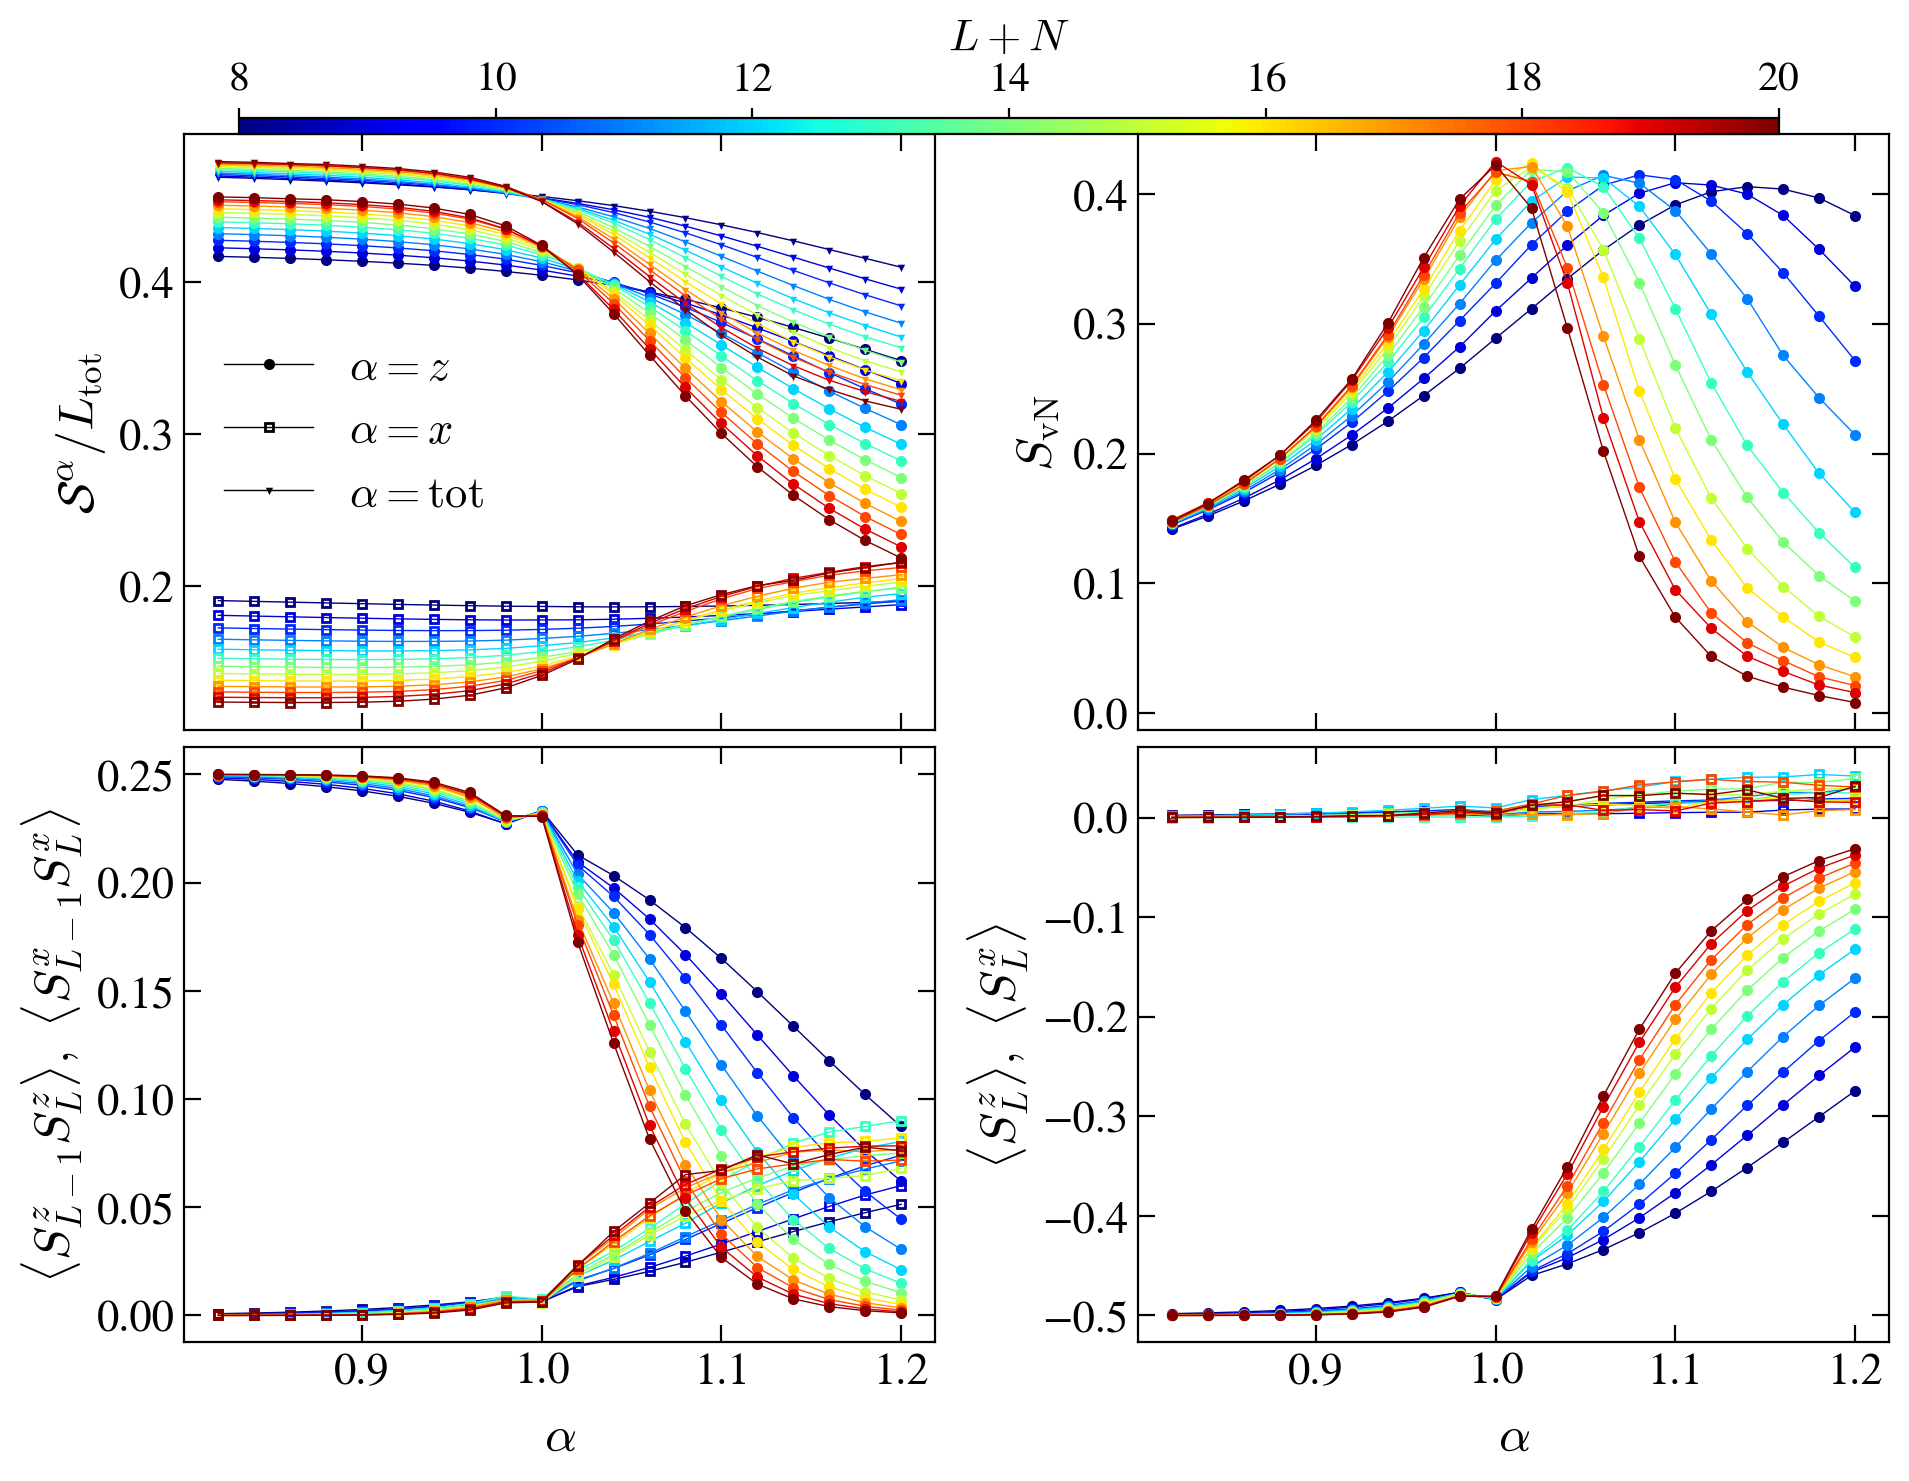

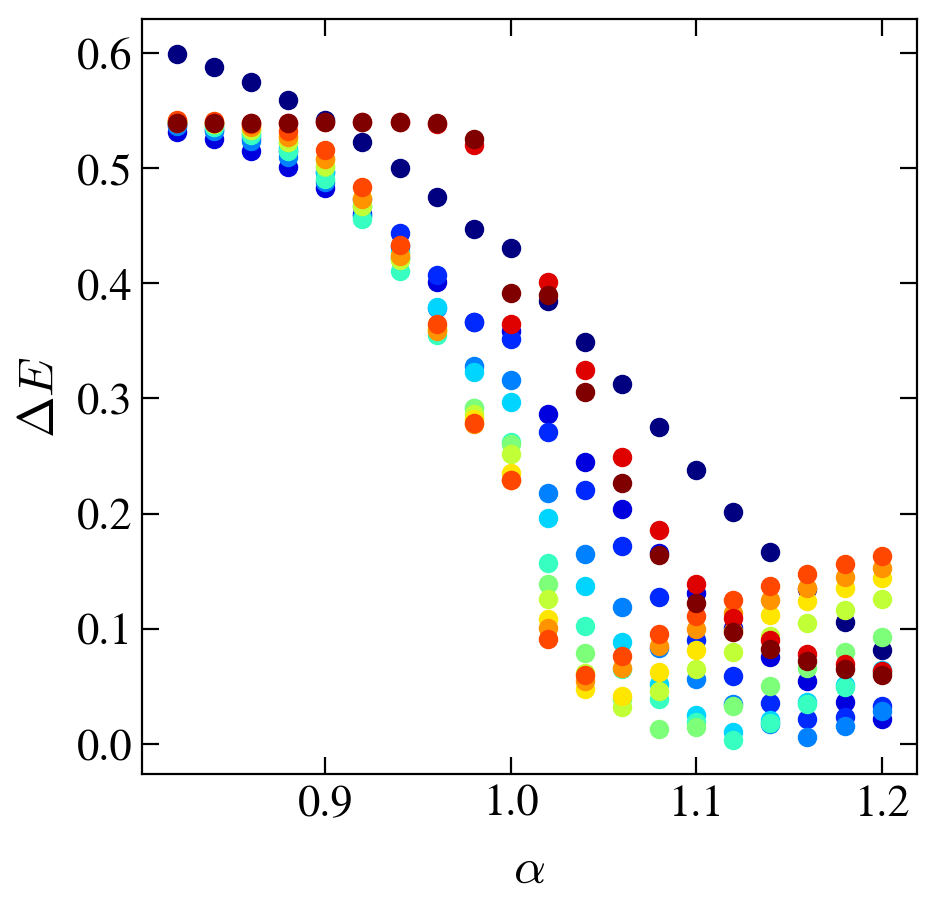

In [473]:
L=21

J=1
alfa=1.0
h=1.0
w=0.5
zeta=0.2
gamma=1.0
conf_disorder = False

N=3
scaled_dis = 0

ini_ave = 0

Ltot = L + N

fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(11, 8), dpi = 200, sharex = True)
axis = axis.flatten()

fig2, ax = plt.subplots( nrows=1, ncols=1, figsize=(5, 5), dpi = 200, sharex = True)

sizes = np.arange(8, 21, 1) if J == 1 else np.arange(11, 19, 1)
norm = matplotlib.colors.Normalize(
    vmin=np.min(sizes),
    vmax=np.max(sizes))


# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

alfa_vals = np.arange(0.82, 1.21, 0.02)
# alfa_vals = [*np.arange(0.8, 1.2, 0.02), *np.arange(1.02, 1.21, 0.02)]
# alfa_vals = [*np.arange(0.983, 1.015, 0.003)]#, *alfa_vals]
alfa_vals = np.sort(np.array(alfa_vals))

state = 'GS'
# state = 'excited'
for L in sizes:
    Ltot = L+N
    col = s_m.to_rgba(L)
    S_from_SzSz = np.zeros(alfa_vals.shape);    S_from_SzSz.fill(np.nan)
    S_from_SxSx = np.zeros(alfa_vals.shape);    S_from_SxSx.fill(np.nan)
    S = np.zeros(alfa_vals.shape);    S.fill(np.nan)
    ent = np.zeros(alfa_vals.shape);    ent.fill(np.nan)
    SzSz = np.zeros(alfa_vals.shape);   SzSz.fill(np.nan)
    SxSx = np.zeros(alfa_vals.shape);   SxSx.fill(np.nan)
    Sz = np.zeros(alfa_vals.shape);     Sz.fill(np.nan)
    Sx = np.zeros(alfa_vals.shape);     Sx.fill(np.nan)
    gap = np.zeros(alfa_vals.shape);    gap.fill(np.nan)
    for iia, alfa in enumerate(alfa_vals):
        name = base_dir + 'GroundState/TESTS/' + info(L=L, N=N, J=J, gamma=gamma, zeta=zeta, alfa=alfa, h=h, w=w, ini_ave = ini_ave, ext='.hdf5', scaled_disorder=scaled_dis)
        if exists(name):
            with h5py.File(name, "r") as file:
                SxSx_GS = np.array(file.get('SxSx ' + state)) #[N:, N:]
                SySy_GS = np.array(file.get('SySy ' + state)) #[N:, N:]
                SzSz_GS = np.array(file.get('SzSz ' + state)) #[N:, N:]
                
                corr = SzSz_GS
                S2 = np.sum(corr.flatten())
                S_from_SzSz[iia] = (1 + np.sqrt(1 + 4 * S2))/2
                
                corr = SxSx_GS
                S2 = np.sum(corr.flatten())
                S_from_SxSx[iia] = (1 + np.sqrt(1 + 4 * S2))/2
                
                corr = SxSx_GS + SySy_GS + SzSz_GS
                S2 = np.sum(corr.flatten())
                S[iia] = (1 + np.sqrt(1 + 4 * S2))/2
                
                ent[iia] = np.array(file.get('entropies ' + state))[N]
                SzSz[iia] = np.array(file.get('SzSz ' + state))[-2,-1]
                SxSx[iia] = np.array(file.get('SxSx ' + state))[-2,-1]
                Sz[iia] = np.array(file.get('Sz ' + state))[-1]
                Sx[iia] = np.array(file.get('Sx ' + state))[-1]
                
                # gap[iia] = np.exp(np.mean( np.log(np.array(file.get('energy gap'))) ))
                gap[iia] = (np.array(file.get('energy gap')))[0]
        else:
            print(name)
    x = alfa_vals[1:-1]
    y = S_from_SzSz[1:-1] / Ltot
    # y = -diff_central(alfa_vals, S)
    
    axis[0].plot(alfa_vals, S_from_SzSz / Ltot, marker='o', markersize=3, lw=0.5, color=col)
    axis[0].plot(alfa_vals, S_from_SxSx / Ltot, marker='s', markersize=3, lw=0.5, color=col, markerfacecolor='None')
    axis[0].plot(alfa_vals, S / Ltot, marker='v', markersize=1, lw=0.5, color=col)
    
    axis[1].plot(alfa_vals, ent, marker='o', markersize=3, lw=0.5, color=col)
    
    axis[2].plot(alfa_vals, SzSz, marker='o' , markersize=3, lw=0.5, color=col)
    axis[2].plot(alfa_vals, SxSx, marker='s', markersize=3, lw=0.5 , color=col, markerfacecolor='None')
    
    axis[3].plot(alfa_vals, Sz, marker='o' , markersize=3, lw=0.5, color=col)
    axis[3].plot(alfa_vals, Sx, marker='s', markersize=3, lw=0.5 , color=col, markerfacecolor='None')

    ax.scatter(alfa_vals, gap, color=col)
    
axis[0].plot(np.nan, np.nan, marker='o', markersize=3, lw=0.5, label = r'$\alpha=z$', color='k')
axis[0].plot(np.nan, np.nan, marker='s', markersize=3, lw=0.5, label = r'$\alpha=x$', color='k', markerfacecolor='None')
axis[0].plot(np.nan, np.nan, marker='v', markersize=1, lw=0.5, label = r'$\alpha={\rm tot}$', color='k')
    
fig_help.set_plot_elements(axis[0], ylabel=r"$\mathcal{S}^\alpha/L_{\rm tot}$", xlabel=r"$\alpha$", font_size=16, set_legend=True, xscale='linear')
fig_help.set_plot_elements(axis[1], ylabel=r"$S_{\rm vN}$", xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear')
fig_help.set_plot_elements(axis[2], ylabel=r"$\langle S^z_{L-1}S^z_{L}\rangle,\ \langle S^x_{L-1}S^x_{L}\rangle$", xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear')
fig_help.set_plot_elements(axis[3], ylabel=r"$\langle S^z_{L}\rangle,\ \langle S^x_{L}\rangle$", xlabel=r"$\alpha$", font_size=16, set_legend=False, xscale='linear')
        
fig_help.set_plot_elements(ax, ylabel=r"$\Delta E$", xlabel=r"$\alpha$", font_size=16, set_legend=True, xscale='linear')

# fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.15, 0.88, 0.7, 0.01])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='horizontal')
cbar.set_label(r"$L+N$", fontsize=16)
cbar.ax.tick_params(labelsize=15)
cbar_ax.xaxis.tick_top()
cbar_ax.xaxis.set_label_position('top')

fig.subplots_adjust(wspace = 0.27, hspace=0.03)

In [288]:
1.05**22

2.925260719921726

In [321]:
np.arange(0.983, 1.017, 0.003)

array([0.983, 0.986, 0.989, 0.992, 0.995, 0.998, 1.001, 1.004, 1.007,
       1.01 , 1.013, 1.016])

In [452]:
(2**20 + 2**21 + 2**22 + 2**23) * 100 * 16 / 10**9 * 20

503.31648